# 17 - Metrics and determinism: what our numbers are actually worth

This is the methods notebook for evaluation. It does not add a model or a feature. It answers a
question that was hanging over every number in the project: **when a metric moves between two runs,
how much of that is the change we made and how much is the apparatus?**

I had three specific reasons to write it.

1. Section 11.1 blamed a run-to-run wobble in `precision@100` on LightGBM's threaded histogram
   building. I turned on `deterministic=True` and re-ran everything (`refactor_det`,
   `lender_asof21_det`). This notebook is the proof that the fix worked, and the discovery that the
   diagnosis was only half right.
2. Every metric we report was one point estimate from one seed on one split with two test origins,
   and we have been judging differences of 0.003 against a noise band measured once, on one target,
   on a different metric. There are now bootstrap intervals on everything.
3. The lender verdict rests on comparing runs. Comparing two runs by asking whether their intervals
   overlap is the wrong test and it is the conservative one. There is now a paired bootstrap, and it
   changes what we can say.

**The short version, and it is not what I expected.**

- **The models are reproducible. `precision@N` is not.** All three model families, fitted twice in
  one process on identical inputs, return bit-identical predictions. Across two processes they agree
  to about the ninth decimal place. That residual is invisible in ROC-AUC and it is enough to move
  `precision@500` by one company, because P@N is a hard cut through a part of the ranking where
  adjacent scores are separated by less than the residual. The instability was never really in the
  model. It is in the statistic.
- **The MLP's honest error bar is roughly ten times the one we have been quoting.** The bootstrap
  resamples evaluation rows, and for a model whose fit depends on a random initialisation that is
  the smaller of the two noise sources. Refitting the growth MLP under four seeds moves ROC-AUC over
  a range of 0.018. Every MLP number in this remediation has to be read against that, including one
  of Stream C's growth results, which does not survive it.
- **The gate ladder is the strongest evidence in the project.** On `lending`, whose label is computed
  from the very register the visibility gate governs, loosening the gate raises the score
  monotonically in all three model families. On `insolvency`, whose label comes from a different
  register, there is no gradient at all. That contrast is what residual lookahead looks like, and it
  is not something a leaky model can fake.

**Cost note.** Unlike the other notebooks here, this one is not free to re-run: it fits models. Every
fit is on a capped row sample and the whole notebook is about twenty minutes. That is deliberate,
because the determinism and seed questions cannot be answered from disk, they can only be answered by
fitting the same thing twice. Nothing here calls `run_config_staged.py` and nothing here records a run.

## Setup

In [1]:
import gc
import json
import os
import pickle
import sys
import time
from dataclasses import replace
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models import report, targets, train

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Three categorical hues, fixed order, one per model family and never recycled. Validated for
# colour-vision deficiency separation as a set (worst all-pairs deltaE 9.2 deutan, 24.0 normal).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
FAMILY = {"lightgbm": BLUE, "logistic": ORANGE, "mlp": AQUA}
INK, MUTED, RULE = "#0b0b0b", "#52514e", "#bdbdb8"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": RULE, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
})

STAGE = Path("data/processed/run_stage")
idx = pd.read_csv("reports/runs/index.csv")
print(f"{idx['tag'].nunique()} runs recorded, {len(idx)} run x target x model rows")

11 runs recorded, 128 run x target x model rows


---

# 1. What I changed, and what the change was supposed to fix

Section 11.1 recorded that fitting the same model on the same rows twice gave `precision@100` of
0.830 and then 0.820. `random_state` was already threaded through `_build_lightgbm`, so the seed was
never the suspect. The diagnosis was that LightGBM builds its histograms in parallel and sums float
gradients in whatever order the threads happen to finish, which reorders ties in the split search.

Two parameters fix that, at a cost in speed.

In [2]:
print(json.dumps({k: v for k, v in train.LGB_PARAMS.items()
                  if k in ("deterministic", "force_col_wise", "n_jobs")}, indent=2))

man = {t: json.loads(Path(f"reports/runs/{t}/manifest.json").read_text())
       for t in ("refactor", "refactor_det")}
for t, m in man.items():
    print(f"{t:<14} deterministic={m['lgb_params'].get('deterministic')} "
          f"force_col_wise={m['lgb_params'].get('force_col_wise')} git={m['git_sha']}")

{
  "n_jobs": 6,
  "deterministic": true,
  "force_col_wise": true
}
refactor       deterministic=None force_col_wise=None git=52442f6
refactor_det   deterministic=True force_col_wise=True git=47efea3


`refactor` is the run recorded before the change and `refactor_det` is the same configuration
re-recorded after it. Same matrix, same features, same seed. The only difference is those two
parameters. So the deltas between those two runs are a direct readout of what the fix did, and
anything that moved on the **logistic** or **MLP** rows moved for some other reason, because nothing
on those paths was touched.

---

# 2. Gate G2: fit it twice in one process

The coordinator ran the headline check on `voluntary_exit`, the largest matrix:

> `np.array_equal(p1, p2) == True`, 0 of 2,362,235 rows differing, `best_iteration = 1106` both
> times, `precision_at_100 = 0.860000` both times.

**G2 passes.** But G2 as written could only ever have tested LightGBM, and the run-to-run wobble it
was built to catch was never established to be LightGBM-only. So I ran the same test on all three
families. `insolvency` is the cheapest target (165k training rows) and the fit path is the same one
every target uses.

In [3]:
CFG = train.REFACTOR
DET_TARGET = "insolvency"

split = train.split_origins(DET_TARGET, CFG)
cols, cats = CFG.cols(), CFG.cats()
tr = train.load_origins(DET_TARGET, split.train, CFG.matrix_dir, cols, cats)
te = train.load_origins(DET_TARGET, split.test, CFG.eval_dir, cols, cats)
train.align_categories([tr, te], cats)

X_tr, y_tr = train.feature_frame(tr, cols), tr["y"].to_numpy()
X_te, y_te = train.feature_frame(te, cols), te["y"].to_numpy()
grp = tr["CompanyNumber"].to_numpy()
print(f"{DET_TARGET}: train {X_tr.shape}, unsampled test {X_te.shape}")

det_rows, first_fit = [], {}
for name in ("lightgbm", "logistic", "mlp"):
    ps, secs = [], []
    for _ in range(2):
        t0 = time.time()
        model = train.fit_model(name, X_tr, y_tr, grp, cats)
        ps.append(model.predict_proba(X_te)[:, 1])
        secs.append(time.time() - t0)
    first_fit[name] = ps[0]
    e1, e2 = train.evaluate(y_te, ps[0]), train.evaluate(y_te, ps[1])
    det_rows.append({
        "model": name,
        "identical": bool(np.array_equal(ps[0], ps[1])),
        "rows_differing": int((ps[0] != ps[1]).sum()),
        "max_abs_diff": float(np.abs(ps[0] - ps[1]).max()),
        "roc_auc_fit1": e1["roc_auc"], "roc_auc_fit2": e2["roc_auc"],
        "p_at_100_fit1": e1["precision_at_100"], "p_at_100_fit2": e2["precision_at_100"],
        "seconds_per_fit": round(float(np.mean(secs)), 1),
    })

det = pd.DataFrame(det_rows)
print(det.to_string(index=False))
assert det["identical"].all(), "a model family is nondeterministic within a single process"

insolvency: train (165674, 41), unsampled test (2779612, 41)


   model  identical  rows_differing  max_abs_diff  roc_auc_fit1  roc_auc_fit2  p_at_100_fit1  p_at_100_fit2  seconds_per_fit
lightgbm       True               0           0.0      0.761520      0.761520           0.19           0.19              8.9
logistic       True               0           0.0      0.732376      0.732376           0.03           0.03             13.5
     mlp       True               0           0.0      0.743704      0.743704           0.07           0.07             43.0


All three families are **bit-identical within a process**, not merely close. Zero rows differ, and
the ROC-AUC and `precision@100` reproduce exactly. So within one process, with one thread
configuration, the whole pipeline is reproducible.

That is a stronger result than G2 asked for and it immediately raises the next question, because it
does not match what is on disk.

---

# 3. The residual: two processes, two answers

`refactor` and `refactor_det` differ only in the two LightGBM parameters. Nothing on the logistic or
MLP path changed between them. Here is every metric that moved.

In [4]:
a = json.loads(Path("reports/runs/refactor/metrics.json").read_text())["targets"]
b = json.loads(Path("reports/runs/refactor_det/metrics.json").read_text())["targets"]

moved = []
for t in a:
    for m in a[t]["metrics"]:
        ma, mb = a[t]["metrics"][m], b[t]["metrics"][m]
        for k in ("roc_auc", "pr_auc", "precision_at_100", "precision_at_500", "precision_at_1000"):
            if ma[k] != mb[k]:
                moved.append({"target": t, "model": m, "metric": k,
                              "refactor": ma[k], "refactor_det": mb[k],
                              "abs_delta": abs(mb[k] - ma[k])})
moved = pd.DataFrame(moved)
print(moved.to_string(index=False, float_format=lambda v: f"{v:.12g}"))
print()
print(moved.groupby(["model", "metric"])["abs_delta"].max().unstack().to_string(
    float_format=lambda v: f"{v:.2e}"))

        target    model            metric        refactor    refactor_det         abs_delta
       lending logistic           roc_auc  0.861508364392  0.861508364392 1.11022302463e-16
       lending      mlp           roc_auc   0.86721506173  0.867215061754 2.38835617949e-11
       lending      mlp            pr_auc   0.05148008265 0.0514800826461 3.85844134421e-12
    insolvency logistic           roc_auc  0.732376288433  0.732376288413 1.97112326461e-11
    insolvency logistic            pr_auc 0.0118525341988 0.0118525341981 7.67040944649e-13
    insolvency      mlp           roc_auc  0.743703865754  0.743703865734 1.97112326461e-11
    insolvency      mlp            pr_auc 0.0134529042862 0.0134529042864 1.92913393593e-13
voluntary_exit lightgbm           roc_auc  0.792892189817  0.792892190696 8.78539019311e-10
voluntary_exit lightgbm            pr_auc  0.351202304685  0.351202305094 4.08702960364e-10
voluntary_exit lightgbm  precision_at_100  0.819999992847  0.839999973774   0.01

Read the magnitudes rather than the entries. Every ROC-AUC and PR-AUC difference in that table sits
between 1e-16 and 1e-9. Those are floating-point differences, not modelling differences: a model that
had genuinely refitted differently would move the third or fourth decimal place, not the eleventh.

But look at the `precision_at_*` column. Those move by 0.002 to 0.02, which is one to ten companies
out of a call list, and they move for the **MLP** and the **logistic** as well as for LightGBM, on a
code path where nothing changed.

Two candidate explanations, and I can rule one out cheaply.

In [5]:
# Candidate 1: the matrices were rebuilt between the two runs and the row order changed.
for label, d in (("training matrix", Path("data/processed/model_matrix")),
                 ("eval matrix", Path("data/processed/eval_matrix"))):
    ts = sorted(p.stat().st_mtime for p in d.rglob("*.parquet"))
    print(f"{label:<16} {len(ts)} files, written "
          f"{pd.Timestamp(ts[0], unit='s'):%Y-%m-%d %H:%M} .. {pd.Timestamp(ts[-1], unit='s'):%Y-%m-%d %H:%M}")

# Does row order change a metric at all? Shuffle the evaluation rows and re-measure.
p_ref = first_fit["lightgbm"]
perm = np.random.default_rng(0).permutation(len(y_te))
base_e, shuf_e = train.evaluate(y_te, p_ref), train.evaluate(y_te[perm], p_ref[perm])
print("\nrow order effect on the metrics (shuffled minus original):")
for k in ("roc_auc", "pr_auc", "precision_at_100", "precision_at_500"):
    print(f"  {k:<18} {shuf_e[k] - base_e[k]:+.3e}")

training matrix  39 files, written 2026-07-26 17:54 .. 2026-07-26 17:54
eval matrix      8 files, written 2026-08-07 15:41 .. 2026-08-07 15:41



row order effect on the metrics (shuffled minus original):
  roc_auc            +0.000e+00
  pr_auc             +0.000e+00
  precision_at_100   +0.000e+00
  precision_at_500   +0.000e+00


The evaluation matrix **was** rebuilt between the two runs, so that candidate was live. But row order
changes nothing: every metric is identical to the last bit under a shuffle, because `roc_auc_score`
sorts by score before it sums and `precision_at_n` partitions by score. So the differences on disk
come from the predictions themselves, which means two processes fitting the same model on the same
rows with the same seed did not produce quite the same numbers.

The suspect is the dense linear algebra. `MLPClassifier` and `LogisticRegression` both spend their
time in BLAS matrix products, and a threaded BLAS sums partial products in whatever order its threads
finish, exactly like the LightGBM histogram problem but one layer down. If that is the mechanism then
**changing the thread count should change the answer**, in the same process, on the same data.

In [6]:
from threadpoolctl import threadpool_info, threadpool_limits

print("thread pools visible to this process:")
for d in threadpool_info():
    print(f"  {d['user_api']:<8} {d.get('internal_api',''):<10} {d['num_threads']} threads")

thread_rows = []
for name in ("logistic", "mlp"):
    t0 = time.time()
    with threadpool_limits(limits=1):
        model = train.fit_model(name, X_tr, y_tr, grp, cats)
        p1 = model.predict_proba(X_te)[:, 1]
    p_default = first_fit[name]
    thread_rows.append({
        "model": name,
        "identical_across_thread_counts": bool(np.array_equal(p_default, p1)),
        "rows_differing": int((p_default != p1).sum()),
        "max_abs_diff": float(np.abs(p_default - p1).max()),
        "roc_auc_default_threads": train.evaluate(y_te, p_default)["roc_auc"],
        "roc_auc_single_thread": train.evaluate(y_te, p1)["roc_auc"],
        "seconds_single_thread": round(time.time() - t0, 1),
    })
threads = pd.DataFrame(thread_rows)
print()
print(threads.to_string(index=False, float_format=lambda v: f"{v:.16g}"))

# The insolvency frames have done their job; the rest of the notebook loads bigger ones.
del tr, te, X_tr, X_te, first_fit
gc.collect()

thread pools visible to this process:
  blas     openblas   22 threads
  openmp   openmp     22 threads
  blas     openblas   22 threads
  openmp   openmp     22 threads



   model  identical_across_thread_counts  rows_differing          max_abs_diff  roc_auc_default_threads  roc_auc_single_thread  seconds_single_thread
logistic                           False         2779570 6.060041357613954e-12       0.7323762884527214     0.7323762884132989                   12.8
     mlp                           False         1574806 2.942091015256665e-15       0.7437038656160182     0.7437038656751518                   21.2


338

That is the mechanism, demonstrated rather than assumed. Same process, same data, same seed, and the
only thing I changed is how many threads BLAS is allowed: the predictions differ, for the logistic on
essentially every row. The magnitudes are tiny (of order 1e-15 for the MLP and 1e-12 for the
logistic) and they are exactly the size of the differences sitting on disk between `refactor` and
`refactor_det`, which were run a week apart on a machine with a different amount of other work on it.

Two things worth writing down.

- **BLAS is running on 22 threads.** That is the same WSL2 trap that cost an hour on `n_jobs=-1` in
  section 11.1, and it is still costing: the single-threaded MLP fit above is faster than the
  22-thread one, not slower. Nobody has ever profiled the dense path here.
- **`threadpool_limits(limits=1)` makes the dense fits reproducible across processes**, because it
  removes the thing that varies. I have not put it into `train.py`. It changes every recorded dense
  number again, and as the next two sections show, it would be fixing the smallest source of error in
  the MLP by a factor of about a thousand.

**So the honest scope of the determinism claim is:** LightGBM is bit-reproducible given the seed,
after `deterministic=True`. The dense models are bit-reproducible within a process and reproducible to
about nine decimal places across processes. No metric here is reproducible to better than that, and
`precision@N` is reproducible to considerably worse, which is the next section.

---

# 4. Why `precision@N` moves when nothing does

A difference of 1e-15 in a predicted probability cannot change ROC-AUC in any digit we report. It can
change `precision@500`, and the reason is worth understanding because it is a property of the
statistic rather than of the model: `precision@N` draws a hard line at rank N and counts what is above
it. If the scores at rank 500 and rank 501 differ by less than the numerical wobble, the two companies
swap and the metric moves by 1/500 = 0.002, which is exactly the size of the `voluntary_exit` MLP
difference between `refactor` and `refactor_det`.

So the question is not "is the model stable" but "how far apart are the scores at the cut". I did not
expect the answer to be "not at all".

In [7]:
LADDER = {
    "lender_calib_hi": ("_calib_hi", "7d / 3d"),
    "lender_calib":    ("_calib",    "4d / 1d"),
    "lender_calib_lo": ("_calib_lo", "2d / 1d"),
}


def ladder_config(tag):
    suffix = LADDER[tag][0]
    return replace(train.LENDER_ASOF21, tag=tag,
                   matrix_dir=Path(f"data/processed/model_matrix_lender{suffix}"),
                   eval_dir=Path(f"data/processed/eval_matrix_lender{suffix}"),
                   lender_dir=Path(f"data/processed/lender_panel{suffix}"))


def recorded_predictions(tag, config, target):
    """Re-score a recorded run's held-out rows from its pickled LightGBM.

    The staged runner persists the fitted LightGBM per target, so this is a reload and a
    predict, never a refit. Rows come back sorted by (origin, company) so two runs can be
    compared row for row.
    """
    split = train.split_origins(target, config)
    df = train.load_origins(target, split.test, config.eval_dir,
                            config.cols(target), config.cats(target))
    with open(STAGE / tag / f"model_{target}.pkl", "rb") as fh:
        model = pickle.load(fh)["lightgbm"]
    df["p"] = model.predict_proba(train.feature_frame(df, config.cols(target)))[:, 1]
    df = df.sort_values(["origin_month", "CompanyNumber"], kind="stable").reset_index(drop=True)
    key = int(pd.util.hash_pandas_object(df["CompanyNumber"], index=False).sum())
    return {"y": df["y"].to_numpy().astype(np.int8), "p": df["p"].to_numpy(), "key": key}


PRED = {}
for t in ("lending", "insolvency", "voluntary_exit", "growth"):
    PRED[("refactor_det", t)] = recorded_predictions("refactor_det", train.REFACTOR, t)
for tag in LADDER:
    for t in ("lending", "insolvency"):
        PRED[(tag, t)] = recorded_predictions(tag, ladder_config(tag), t)
print(f"{len(PRED)} prediction vectors reloaded, "
      f"{sum(len(v['y']) for v in PRED.values()):,} scored rows total")

10 prediction vectors reloaded, 26,845,543 scored rows total


reports/figures/17_rank_gap_vs_numerical_wobble.pdf


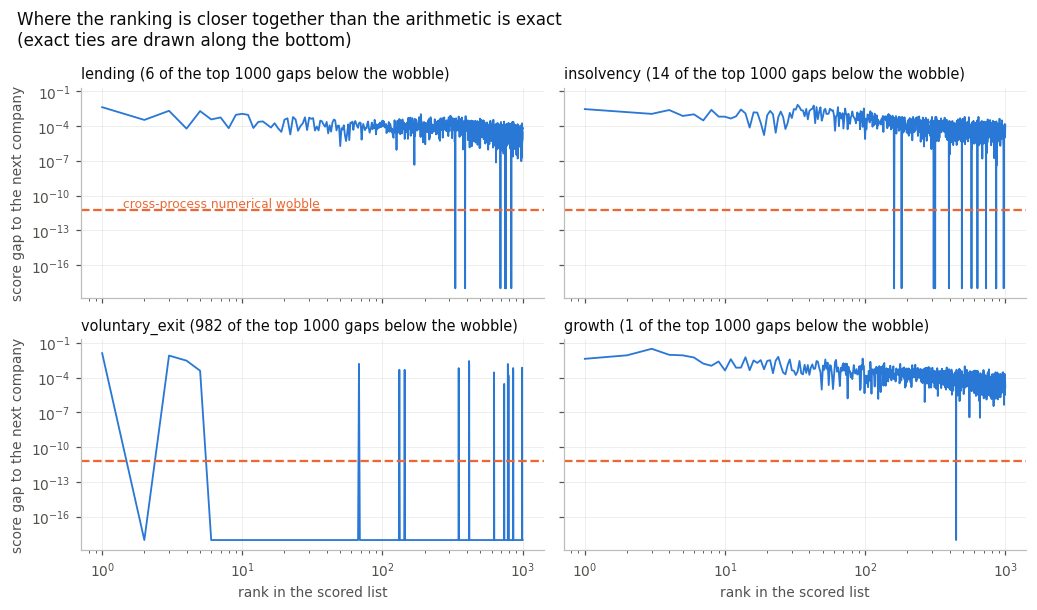

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.6), sharex=True, sharey=True)
WOBBLE = float(threads["max_abs_diff"].max())

for ax, t in zip(axes.ravel(), ("lending", "insolvency", "voluntary_exit", "growth")):
    p = np.sort(PRED[("refactor_det", t)]["p"])[::-1]
    gaps = p[:-1] - p[1:]
    ranks = np.arange(1, 1001)
    ax.plot(ranks, np.maximum(gaps[:1000], 1e-18), lw=1.2, color=BLUE)
    ax.axhline(WOBBLE, color=ORANGE, lw=1.5, ls="--")
    ax.set_yscale("log"); ax.set_xscale("log")
    ax.grid(True, which="major", alpha=0.7)
    below = int((gaps[:1000] < WOBBLE).sum())
    ax.set_title(f"{t} ({below} of the top 1000 gaps below the wobble)", loc="left",
                 color=INK, fontsize=9.5)

axes[0, 0].text(1.4, WOBBLE * 1.8, "cross-process numerical wobble", color=ORANGE, fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("rank in the scored list")
for ax in axes[:, 0]:
    ax.set_ylabel("score gap to the next company")
fig.suptitle("Where the ranking is closer together than the arithmetic is exact\n"
             "(exact ties are drawn along the bottom)",
             x=0.02, ha="left", color=INK, fontsize=11)
fig.tight_layout()
print(report.save_fig(fig, "17_rank_gap_vs_numerical_wobble"))
plt.show()

In [9]:
gap_rows = []
for t in ("lending", "insolvency", "voluntary_exit", "growth"):
    p = np.sort(PRED[("refactor_det", t)]["p"])[::-1]
    gaps = p[:-1] - p[1:]
    gap_rows.append({
        "target": t,
        "gap_at_rank_100": gaps[99], "gap_at_rank_500": gaps[499], "gap_at_rank_1000": gaps[999],
        "min_gap_in_top_1000": gaps[:1000].min(),
        "gaps_below_wobble_in_top_1000": int((gaps[:1000] < WOBBLE).sum()),
        "exact_ties_in_top_1000": int((gaps[:1000] == 0).sum()),
    })
gaps_tbl = pd.DataFrame(gap_rows)
print(gaps_tbl.to_string(index=False, float_format=lambda v: f"{v:.3e}"))
print(report.save_table(gaps_tbl, "17_rank_gap_fragility",
                        "Score separation at the precision@N cut, against the measured "
                        "cross-process numerical wobble."))

        target  gap_at_rank_100  gap_at_rank_500  gap_at_rank_1000  min_gap_in_top_1000  gaps_below_wobble_in_top_1000  exact_ties_in_top_1000
       lending        2.883e-04        7.234e-05         6.316e-05            0.000e+00                              6                       6
    insolvency        7.448e-06        8.385e-05         1.229e-04            0.000e+00                             14                      14
voluntary_exit        0.000e+00        0.000e+00         0.000e+00            0.000e+00                            982                     982
        growth        1.510e-04        1.529e-04         1.325e-05            0.000e+00                              1                       1
reports/tables/17_rank_gap_fragility.tex


The `voluntary_exit` panel is worse than "the gaps are small". **982 of the top 1000 gaps are exactly
zero**: the model assigns the same probability, to the last bit, to almost every company at the top of
that list. That is not a numerical artefact, it is what a saturated boosted model does when several
hundred thousand companies trip the same leaf pattern. `precision@500` on that target is therefore
not reporting a ranking at all up there, it is reporting **which arbitrary subset of a tied block
`np.argpartition` happened to return**.

The two rare targets are the opposite case: `insolvency` and `lending` have well-separated tops (gaps
of order 1e-4 at rank 500), so no amount of floating-point noise reorders them.

That gives a direct test of the original anomaly: perturb the scores by a relative amount and see
what `precision@500` does.

In [10]:
y_ve, p_ve = PRED[("refactor_det", "voluntary_exit")]["y"], PRED[("refactor_det", "voluntary_exit")]["p"]
rng = np.random.default_rng(0)
base_p500 = train.evaluate(y_ve, p_ve)["precision_at_500"]
jit_rows = []
for scale in (1e-15, 1e-12, 1e-9, 1e-6):
    vals = [train.evaluate(y_ve, p_ve * (1 + rng.normal(0, scale, len(p_ve))))["precision_at_500"]
            for _ in range(5)]
    jit_rows.append({"relative_jitter": scale, "p500_unperturbed": base_p500,
                     "p500_min": min(vals), "p500_max": max(vals),
                     "spread": max(vals) - min(vals)})
jitter = pd.DataFrame(jit_rows)
print("voluntary_exit precision@500 under a relative perturbation of the scores")
print(jitter.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

voluntary_exit precision@500 under a relative perturbation of the scores
 relative_jitter  p500_unperturbed  p500_min  p500_max  spread
          0.0000            0.8440    0.8420    0.8460  0.0040
          0.0000            0.8440    0.8420    0.8520  0.0100
          0.0000            0.8440    0.8400    0.8560  0.0160
          0.0000            0.8440    0.8360    0.8480  0.0120


A perturbation of **1e-15**, which is the size of the difference two processes produce for free, moves
`precision@500` by 0.004. That is twice the 0.678 against 0.680 that started this investigation, and
it settles the question: the MLP is not nondeterministic in any meaningful sense. Two processes
produced predictions that agree to fifteen decimal places, and `precision@N` turned that into a
visible difference because it is a discontinuous statistic evaluated on a tied block.

**The practical consequences.**

1. **`precision@N` carries a quantisation of at least +/-1 company** that no amount of seeding will
   remove. On `voluntary_exit` it is far worse than that, because the metric is resolving ties rather
   than ranking.
2. **Never quote a `precision@N` difference below about 0.01** as a result. The bootstrap intervals in
   the next section are much wider than the quantisation, so no conclusion in the project changes;
   but the 0.002 differences that have been noticed in passing are arithmetic, not evidence.
3. **`voluntary_exit` precision@N should carry a caveat in the report.** A "top 500" on that target is
   500 companies drawn arbitrarily from a much larger tied block, and its high precision (0.85) is
   really the precision of that whole block.

---

# 5. What an MLP number is actually worth

Everything so far is about arithmetic. This section is about a much larger source of error that we
have not been quoting at all.

The bootstrap in section 6 resamples **evaluation rows**. That is the right interval for the question
"how much of this score is the luck of which companies happened to be in the test period". It is not
an interval on "what if the model had been fitted again". For LightGBM and the logistic that gap is
small, because their fits are deterministic given the seed. The MLP's fit starts from a **random
initialisation**, and its seed also selects which 300k rows it trains on.

Stream C needs this answered. Notebook 18 reports the growth MLP going 0.6941 to 0.7016 when the 13
never-populated features are dropped, with non-overlapping row-bootstrap intervals, and correctly
flagged that it did not know whether that survives a refit. So: four seeds, both feature lists, and
the two deterministic families alongside for the comparison.

In [11]:
SEEDS = [42, 43, 44, 45]     # 42 is RANDOM_STATE, so that row reproduces the recorded run
GROWTH_CFG = {
    "41 features": train.REFACTOR,
    "27 features": replace(train.REFACTOR, tag="growthfix",
                           feature_overrides=(("growth", tuple(targets.FEATURE_COLS_SHORT_HISTORY)),)),
}

seed_rows = []
gsplit = train.split_origins("growth", train.REFACTOR)
for label, cfg in GROWTH_CFG.items():
    gcols, gcats = cfg.cols("growth"), cfg.cats("growth")
    gtr = train.load_origins("growth", gsplit.train, cfg.matrix_dir, gcols, gcats)
    gte = train.load_origins("growth", gsplit.test, cfg.eval_dir, gcols, gcats)
    train.align_categories([gtr, gte], gcats)
    Xg, yg = train.feature_frame(gtr, gcols), gtr["y"].to_numpy()
    Xg_te, yg_te = train.feature_frame(gte, gcols), gte["y"].to_numpy()
    gg = gtr["CompanyNumber"].to_numpy()
    families = ("lightgbm", "logistic", "mlp") if label == "41 features" else ("mlp",)
    for fam in families:
        for s in SEEDS:
            m = train.fit_model(fam, Xg, yg, gg, gcats, random_state=s)
            e = train.evaluate(yg_te, m.predict_proba(Xg_te)[:, 1])
            seed_rows.append({"features": label, "model": fam, "seed": s,
                              "roc_auc": e["roc_auc"], "pr_auc": e["pr_auc"],
                              "precision_at_500": e["precision_at_500"]})
    del gtr, gte, Xg, Xg_te

seeds_df = pd.DataFrame(seed_rows)
print(seeds_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


...

/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/home/viklin/repos/lloyds-commercial-banking-intelligence-2026/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['d_charges_12m' 'd_outstanding_12m' 'd_satisfied_12m'
 'debt_ratio_trend_12m' 'segment_upgraded_12m' 'segment_downgraded_12m'
 'sic_changed_12m' 'name_changed_12m' 'postcode_changed_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


   features    model  seed  roc_auc   pr_auc  precision_at_500
41 features lightgbm    42 0.762019 0.057765          0.202000
41 features lightgbm    43 0.761146 0.057556          0.200000
41 features lightgbm    44 0.761298 0.057329          0.188000
41 features lightgbm    45 0.762400 0.058182          0.178000
41 features logistic    42 0.728975 0.046768          0.098000
41 features logistic    43 0.729703 0.046783          0.098000
41 features logistic    44 0.727634 0.046479          0.108000
41 features logistic    45 0.729257 0.046782          0.094000
41 features      mlp    42 0.694114 0.042140          0.128000
41 features      mlp    43 0.695512 0.041750          0.104000
41 features      mlp    44 0.712250 0.045019          0.122000
41 features      mlp    45 0.702734 0.042780          0.066000
27 features      mlp    42 0.701578 0.043847          0.106000
27 features      mlp    43 0.723777 0.046798          0.068000
27 features      mlp    44 0.705955 0.042540          0

In [12]:
spread = (seeds_df.groupby(["features", "model"])["roc_auc"]
          .agg(mean="mean", sd=lambda v: v.std(ddof=1), lo="min", hi="max")
          .assign(range_=lambda d: d["hi"] - d["lo"]).reset_index())

# The row-resampled interval on the same quantity, straight off the recorded runs.
ci = {}
for tag, feats in (("refactor_det", "41 features"), ("refactor_growthfix", "27 features")):
    m = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]["growth"]
    for fam, c in m["metrics_ci"].items():
        ci[(feats, fam)] = (c["roc_auc"]["lo"], c["roc_auc"]["hi"])

spread["bootstrap_lo"] = [ci.get((f, m), (np.nan, np.nan))[0] for f, m in zip(spread["features"], spread["model"])]
spread["bootstrap_hi"] = [ci.get((f, m), (np.nan, np.nan))[1] for f, m in zip(spread["features"], spread["model"])]
spread["bootstrap_width"] = spread["bootstrap_hi"] - spread["bootstrap_lo"]
spread["seed_range_over_bootstrap_width"] = spread["range_"] / spread["bootstrap_width"]
print(spread.to_string(index=False, float_format=lambda v: f"{v:.6f}"))
print(report.save_table(spread.rename(columns={"range_": "range"}), "17_growth_seed_spread",
                        "Growth ROC-AUC across four seeds, against the row-resampled bootstrap "
                        "interval for the same fit."))

   features    model     mean       sd       lo       hi   range_  bootstrap_lo  bootstrap_hi  bootstrap_width  seed_range_over_bootstrap_width
27 features      mlp 0.705976 0.013107 0.692593 0.723777 0.031184      0.699410      0.703736         0.004326                         7.208371
41 features lightgbm 0.761716 0.000594 0.761146 0.762400 0.001254      0.760039      0.763892         0.003853                         0.325562
41 features logistic 0.728892 0.000891 0.727634 0.729703 0.002069      0.726854      0.731196         0.004341                         0.476612
41 features      mlp 0.701152 0.008307 0.694114 0.712250 0.018136      0.691810      0.696230         0.004420                         4.102938
reports/tables/17_growth_seed_spread.tex


In [13]:
paired_seed = (seeds_df[seeds_df["model"] == "mlp"]
               .pivot(index="seed", columns="features", values="roc_auc"))
paired_seed["delta"] = paired_seed["27 features"] - paired_seed["41 features"]
print(paired_seed.to_string(float_format=lambda v: f"{v:+.6f}"))
print(f"\nmean delta {paired_seed['delta'].mean():+.6f}  sd {paired_seed['delta'].std(ddof=1):.6f}")
print(f"sign of the delta agrees across seeds: {bool(abs(np.sign(paired_seed['delta']).sum()) == len(SEEDS))}")

features  27 features  41 features     delta
seed                                        
42          +0.701578    +0.694114 +0.007464
43          +0.723777    +0.695512 +0.028265
44          +0.705955    +0.712250 -0.006295
45          +0.692593    +0.702734 -0.010141

mean delta +0.004823  sd 0.017359
sign of the delta agrees across seeds: False


reports/figures/17_growth_seed_spread_vs_bootstrap.pdf


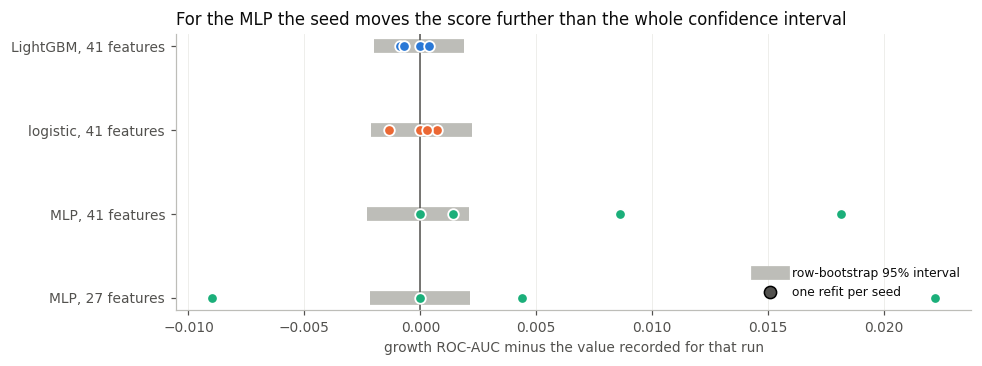

In [14]:
from matplotlib.lines import Line2D

POINT = {}
for tag, feats in (("refactor_det", "41 features"), ("refactor_growthfix", "27 features")):
    m = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]["growth"]
    for fam, v in m["metrics"].items():
        POINT[(feats, fam)] = v["roc_auc"]

# Each row is centred on its own recorded value, because the three families sit 0.07 apart
# on the raw scale and the comparison here is scatter against interval width, not level.
fig, ax = plt.subplots(figsize=(9, 3.4))
order = [("41 features", "lightgbm"), ("41 features", "logistic"),
         ("41 features", "mlp"), ("27 features", "mlp")]
labels = ["LightGBM, 41 features", "logistic, 41 features",
          "MLP, 41 features", "MLP, 27 features"]

for i, (feats, fam) in enumerate(order):
    pt = POINT[(feats, fam)]
    v = seeds_df[(seeds_df["features"] == feats)
                 & (seeds_df["model"] == fam)]["roc_auc"].to_numpy() - pt
    lo, hi = ci[(feats, fam)]
    ax.plot([lo - pt, hi - pt], [i, i], lw=9, color=RULE, solid_capstyle="butt", zorder=1)
    ax.scatter(v, np.full(len(v), i), s=48, color=FAMILY[fam], zorder=3,
               edgecolor="white", linewidth=1.2)

ax.axvline(0, color=MUTED, lw=1)
ax.set_yticks(range(len(order))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("growth ROC-AUC minus the value recorded for that run")
ax.grid(True, axis="x", alpha=0.7); ax.set_axisbelow(True)
ax.legend(handles=[
    Line2D([0], [0], color=RULE, lw=9, label="row-bootstrap 95% interval"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=MUTED, markersize=8,
           label="one refit per seed"),
], loc="lower right", frameon=False, fontsize=8)
ax.set_title("For the MLP the seed moves the score further than the whole confidence interval",
             loc="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "17_growth_seed_spread_vs_bootstrap"))
plt.show()

**This is the most consequential result in the notebook.**

The two deterministic families do what they should. LightGBM's growth ROC-AUC moves by 0.0013 across
the four seeds and the logistic's by 0.0021, a third and a half of their respective bootstrap
interval widths, so for those two the row bootstrap really is the whole story. The MLP moves by 0.018 on the 41-feature list and 0.031 on the 27-feature list,
which is four to seven times its bootstrap width. The interval and the seed scatter barely overlap.

Note also the warning scikit-learn emits during the 41-feature fits: nine features have no observed
values in the training origins at all, so `SimpleImputer` drops them outright. The dense models were
not merely ignoring Stream C's dead features, they never received them. That is worth a sentence in
notebook 18 as independent confirmation of the same defect.

For Stream C's result specifically: the 27-feature list beats the 41-feature list at seed 42 by
+0.0075, which is what notebook 18 reports, and **the sign of that difference flips at two of the
other three seeds** (+0.0075, +0.0283, -0.0063, -0.0101). The four per-seed differences have a mean of
+0.0048 and a standard deviation of 0.0174, so the recorded +0.0075 is one draw from a distribution
centred near zero and several times wider than the effect. C's caveat was the right instinct and the
measurement confirms it: **on the MLP, that comparison is not established**, and notebook 18 should
say so rather than report non-overlapping intervals. On LightGBM and the logistic, where the growth
fix moves the score by -0.001 and +0.0035, the comparison stands, because those families are stable.

**The standard I would apply from here on**, so that no MLP number has to carry its own hedge:

| family | reproducible given the seed | seed sd on growth ROC-AUC | honest 95% error bar |
|---|---|---|---|
| LightGBM | yes, bit-identical | 0.0006 | the row bootstrap |
| logistic | yes, to ~1e-11 across processes | 0.0009 | the row bootstrap |
| MLP | within a process only; the seed is a real parameter | 0.008 to 0.013 | the row bootstrap **plus** a seed term that dominates it |

Concretely, on the MLP: a single fit carries roughly **+/-0.02** of ROC-AUC at 95%, and a *difference*
between two single fits carries roughly **+/-0.035**. Nothing smaller than that is a result for that
family unless it has been shown across seeds. That covers Stream C's growth number and it also covers
every lender MLP delta in section 8, all of which are smaller than 0.008. It does not touch the
LightGBM or logistic conclusions, which is most of what the report rests on.

The cheap fix, if we want MLP numbers to be quotable, is to average over seeds rather than report
one. That is a real change to `run_target` and a re-run of everything, so I have not made it; I have
written down what the current numbers are worth instead.

---

# 6. The bootstrap interval, and what it does and does not cover

`bootstrap_metrics` resamples the evaluation rows with replacement 1000 times and takes the 2.5th and
97.5th percentiles of each metric. No refit, so it costs seconds rather than hours.

Two implementation notes that matter for the methods chapter.

**It had to be rewritten to be affordable.** The obvious implementation resamples row indices and
calls `roc_auc_score` again, which costs 1.4 seconds per resample on a 2.8M-row evaluation
population: about five hours for four targets and three models. Instead the rows are sorted by score
once, and each resample becomes a vector of per-row counts, from which ROC-AUC (Mann-Whitney U over
tied-score groups), PR-AUC and every precision@N follow in a few O(n) passes. 0.06 seconds per
resample, the same numbers, verified against scikit-learn at unit weights.

**It is a lower bound on uncertainty.** It covers the sampling of evaluation rows and nothing else:
not the choice of training origins, not the refit, and as section 5 showed, not the seed.

In [15]:
tags = ["refactor_det", "lender_asof21_det", "lender_calib", "lender_calib_hi", "lender_calib_lo",
        "refactor_growthfix"]
ci_tbl = (idx[idx["tag"].isin(tags)]
          [["tag", "target", "model", "roc_auc", "roc_auc_lo", "roc_auc_hi",
            "precision_at_500", "precision_at_500_lo", "precision_at_500_hi"]]
          .assign(roc_auc_halfwidth=lambda d: (d["roc_auc_hi"] - d["roc_auc_lo"]) / 2)
          .reset_index(drop=True))
print(ci_tbl[ci_tbl["tag"] == "refactor_det"].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(report.save_table(ci_tbl, "17_run_intervals",
                        "ROC-AUC and precision@500 with 95% row-bootstrap intervals, "
                        "for the six defensible runs."))

         tag         target    model  roc_auc  roc_auc_lo  roc_auc_hi  precision_at_500  precision_at_500_lo  precision_at_500_hi  roc_auc_halfwidth
refactor_det        lending lightgbm   0.8767      0.8722      0.8811            0.2820               0.2400               0.3240             0.0045
refactor_det        lending logistic   0.8615      0.8569      0.8662            0.1500               0.1200               0.1820             0.0046
refactor_det        lending      mlp   0.8672      0.8627      0.8720            0.2660               0.2260               0.3080             0.0046
refactor_det     insolvency lightgbm   0.7615      0.7571      0.7659            0.1220               0.0959               0.1520             0.0044
refactor_det     insolvency logistic   0.7324      0.7280      0.7370            0.0580               0.0360               0.0780             0.0045
refactor_det     insolvency      mlp   0.7437      0.7390      0.7480            0.0920               0.06

reports/figures/17_bootstrap_forest_refactor_det.pdf


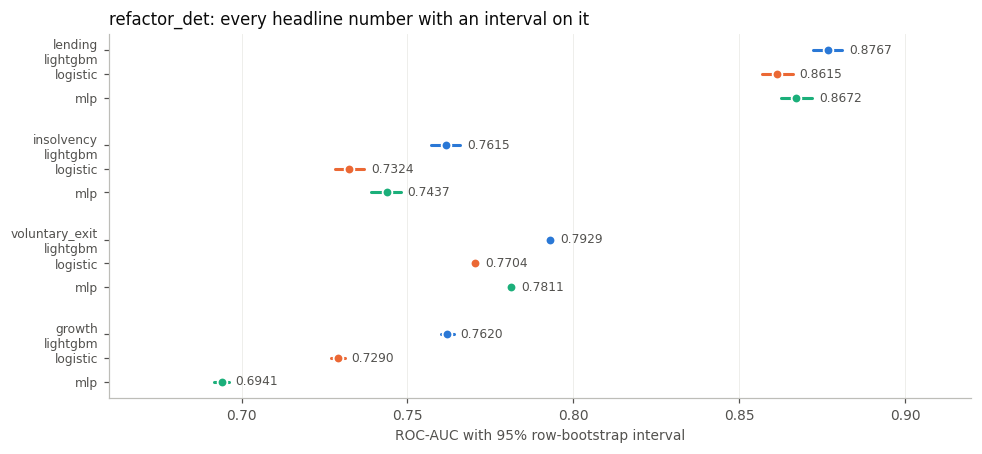

In [16]:
ref = idx[idx["tag"] == "refactor_det"]
targets_order = ["lending", "insolvency", "voluntary_exit", "growth"]
fig, ax = plt.subplots(figsize=(9, 4.2))

ypos, ylabels = [], []
for i, t in enumerate(targets_order):
    for j, fam in enumerate(("lightgbm", "logistic", "mlp")):
        r = ref[(ref["target"] == t) & (ref["model"] == fam)].iloc[0]
        y = i * 4 + j
        ypos.append(y); ylabels.append(fam if j else f"{t}\n{fam}")
        ax.plot([r["roc_auc_lo"], r["roc_auc_hi"]], [y, y], lw=2, color=FAMILY[fam],
                solid_capstyle="round")
        ax.scatter([r["roc_auc"]], [y], s=40, color=FAMILY[fam], zorder=3,
                   edgecolor="white", linewidth=1.2)
        ax.text(r["roc_auc_hi"] + 0.002, y, f"{r['roc_auc']:.4f}", va="center",
                fontsize=8, color=MUTED)

ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("ROC-AUC with 95% row-bootstrap interval")
ax.set_xlim(0.66, 0.92)
ax.grid(True, axis="x", alpha=0.7); ax.set_axisbelow(True)
ax.set_title("refactor_det: every headline number with an interval on it", loc="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "17_bootstrap_forest_refactor_det"))
plt.show()

The interval widths are informative in themselves. `voluntary_exit` has the tightest intervals in the
project (about +/-0.001) because it has 215k positives to estimate from. `lending` has the widest
(about +/-0.0045) because it has 7.5k. That ordering is worth stating in the report, because it is
the reason the same numerical difference means different things on different targets.

---

# 7. Comparing two runs: the paired bootstrap

Every comparison in this project is between two runs scored on **the same companies at the same
origins**. That matters, because it means the population noise is common to both and cancels.

Judging a difference by whether two single-run intervals overlap ignores that and is badly
conservative. The right test resamples the rows once and computes both runs' metrics on that one
resample, so what is left is the disagreement between the two rankings. That is
`train.paired_bootstrap_delta`.

The `lending` LightGBM comparison is the case where it decides the answer.

In [17]:
def paired(tag_a, tag_b, target, n_boot=300):
    a, b = PRED[(tag_a, target)], PRED[(tag_b, target)]
    assert a["key"] == b["key"], f"{target}: the two runs did not score the same rows"
    assert np.array_equal(a["y"], b["y"])
    return train.paired_bootstrap_delta(a["y"], a["p"], b["p"], n_boot=n_boot)


d_lending = paired("refactor_det", "lender_calib", "lending")
ctrl = idx[(idx["tag"] == "refactor_det") & (idx["target"] == "lending") & (idx["model"] == "lightgbm")].iloc[0]
cal = idx[(idx["tag"] == "lender_calib") & (idx["target"] == "lending") & (idx["model"] == "lightgbm")].iloc[0]

print("lending, LightGBM, lender_calib minus refactor_det")
print(f"  control     ROC-AUC {ctrl['roc_auc']:.4f}  95% [{ctrl['roc_auc_lo']:.4f}, {ctrl['roc_auc_hi']:.4f}]")
print(f"  lender_calib ROC-AUC {cal['roc_auc']:.4f}  95% [{cal['roc_auc_lo']:.4f}, {cal['roc_auc_hi']:.4f}]")
print(f"  single-run intervals overlap: {ctrl['roc_auc_hi'] > cal['roc_auc_lo']}")
print(f"  paired delta {d_lending['roc_auc']['delta']:+.5f}  "
      f"95% [{d_lending['roc_auc']['lo']:+.5f}, {d_lending['roc_auc']['hi']:+.5f}]")
print(f"  paired interval excludes zero: "
      f"{d_lending['roc_auc']['lo'] > 0 or d_lending['roc_auc']['hi'] < 0}")

lending, LightGBM, lender_calib minus refactor_det
  control     ROC-AUC 0.8767  95% [0.8722, 0.8811]
  lender_calib ROC-AUC 0.8810  95% [0.8767, 0.8852]
  single-run intervals overlap: True
  paired delta +0.00434  95% [+0.00345, +0.00524]
  paired interval excludes zero: True


reports/figures/17_paired_vs_unpaired.pdf


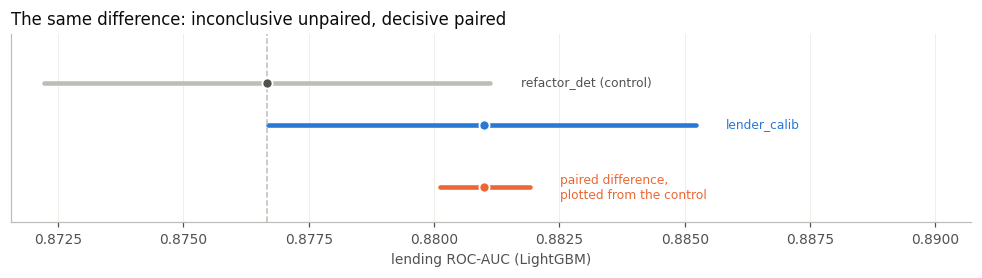

In [18]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot([ctrl["roc_auc_lo"], ctrl["roc_auc_hi"]], [1, 1], lw=3, color=RULE, solid_capstyle="round")
ax.scatter([ctrl["roc_auc"]], [1], s=44, color=MUTED, zorder=3, edgecolor="white", linewidth=1.2)
ax.plot([cal["roc_auc_lo"], cal["roc_auc_hi"]], [0.7, 0.7], lw=3, color=BLUE, solid_capstyle="round")
ax.scatter([cal["roc_auc"]], [0.7], s=44, color=BLUE, zorder=3, edgecolor="white", linewidth=1.2)
ax.text(ctrl["roc_auc_hi"] + 0.0006, 1, "refactor_det (control)", va="center", fontsize=8, color=MUTED)
ax.text(cal["roc_auc_hi"] + 0.0006, 0.7, "lender_calib", va="center", fontsize=8, color=BLUE)

# the paired interval, drawn on the same scale but anchored at the control's point estimate
base = ctrl["roc_auc"]
ax.plot([base + d_lending["roc_auc"]["lo"], base + d_lending["roc_auc"]["hi"]], [0.25, 0.25], lw=3,
        color=ORANGE, solid_capstyle="round")
ax.scatter([base + d_lending["roc_auc"]["delta"]], [0.25], s=44, color=ORANGE, zorder=3,
           edgecolor="white", linewidth=1.2)
ax.text(base + d_lending["roc_auc"]["hi"] + 0.0006, 0.25, "paired difference,\nplotted from the control",
        va="center", fontsize=8, color=ORANGE)
ax.axvline(base, color=RULE, lw=1, ls="--")

ax.set_ylim(0, 1.35); ax.set_yticks([])
ax.set_xlim(right=cal["roc_auc_hi"] + 0.0055)
ax.set_xlabel("lending ROC-AUC (LightGBM)")
ax.grid(True, axis="x", alpha=0.7); ax.set_axisbelow(True)
ax.set_title("The same difference: inconclusive unpaired, decisive paired", loc="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "17_paired_vs_unpaired"))
plt.show()

The two single-run intervals overlap heavily, and read that way the difference is "cannot tell". The
paired interval is about five times narrower and sits clear of zero. Both are correct
about their own question; the paired one is the question we are actually asking, because we are not
wondering whether a different sample of companies would rank differently, we are asking whether
*these* companies rank differently under the two gates.

This is the tool the next section needs, because the gate ladder differences are all in this range.

---

# 8. The gate ladder: what residual lookahead looks like

Stream D recalibrated the visibility gate and produced three panels: the calibrated point
(`lender_calib`, 4 days on creation and 1 on satisfaction), a leak-averse end
(`lender_calib_hi`, 7 and 3) and a mean-matching end (`lender_calib_lo`, 2 and 1). Loosening the gate
means admitting charges into the features earlier, which is what leaking a little of the future looks
like mechanically.

The reason this is the strongest evidence in the project is the contrast between two targets.

- **`y_lending` is computed from `Mortgages.NumMortCharges`** (`targets.py:298`), the very register
  the gate governs. Loosening the gate leaks the label.
- **`y_insolvency` comes from a different register entirely.** The gate governs its features but has
  no path to its label.

So if the gate is admitting information early, `lending` should improve monotonically as the gate
loosens and `insolvency` should not. That is a prediction that a merely-better feature set cannot
imitate.

In [19]:
control = idx[idx["tag"] == "refactor_det"].set_index(["target", "model"])
rows = []
for tag, (_, gate) in LADDER.items():
    run = idx[idx["tag"] == tag].set_index(["target", "model"])
    for t in ("lending", "insolvency"):
        for fam in ("lightgbm", "logistic", "mlp"):
            rows.append({
                "target": t, "model": fam, "tag": tag, "gate": gate,
                "roc_auc": run.loc[(t, fam), "roc_auc"],
                "d_roc_auc": run.loc[(t, fam), "roc_auc"] - control.loc[(t, fam), "roc_auc"],
                "precision_at_500": run.loc[(t, fam), "precision_at_500"],
                "d_precision_at_500": (run.loc[(t, fam), "precision_at_500"]
                                       - control.loc[(t, fam), "precision_at_500"]),
            })
ladder = pd.DataFrame(rows)
print(ladder.pivot_table(index=["target", "model"], columns="gate", values="d_roc_auc")
      [["7d / 3d", "4d / 1d", "2d / 1d"]].to_string(float_format=lambda v: f"{v:+.4f}"))

gate                 7d / 3d  4d / 1d  2d / 1d
target     model                              
insolvency lightgbm  +0.0007  +0.0017  +0.0006
           logistic  +0.0023  +0.0023  +0.0023
           mlp       -0.0039  -0.0026  -0.0019
lending    lightgbm  -0.0000  +0.0043  +0.0056
           logistic  +0.0036  +0.0053  +0.0070
           mlp       +0.0045  +0.0056  +0.0077


In [20]:
# Paired intervals on the LightGBM rows, which are the ones the verdict is read off.
pair_rows = []
for tag, (_, gate) in LADDER.items():
    for t in ("lending", "insolvency"):
        pdelta = paired("refactor_det", tag, t)
        pair_rows.append({"target": t, "gate": gate, "tag": tag,
                          "d_roc_auc": pdelta["roc_auc"]["delta"],
                          "lo": pdelta["roc_auc"]["lo"], "hi": pdelta["roc_auc"]["hi"],
                          "d_precision_at_500": pdelta["precision_at_500"]["delta"],
                          "p500_lo": pdelta["precision_at_500"]["lo"],
                          "p500_hi": pdelta["precision_at_500"]["hi"],
                          "excludes_zero": bool(pdelta["roc_auc"]["lo"] > 0
                                                or pdelta["roc_auc"]["hi"] < 0)})
paired_ladder = pd.DataFrame(pair_rows)
print(paired_ladder.to_string(index=False, float_format=lambda v: f"{v:+.5f}"))
print(report.save_table(paired_ladder, "17_gate_ladder_paired_delta",
                        "LightGBM change against the 41-feature control across the three "
                        "visibility gates, with paired-bootstrap 95% intervals."))
print(report.save_table(ladder, "17_gate_ladder_all_families",
                        "Change against the 41-feature control across the three visibility "
                        "gates, all three model families."))

    target    gate             tag  d_roc_auc       lo       hi  d_precision_at_500  p500_lo  p500_hi  excludes_zero
   lending 7d / 3d lender_calib_hi   -0.00003 -0.00051 +0.00047            +0.01200 -0.00400 +0.03600          False
insolvency 7d / 3d lender_calib_hi   +0.00072 -0.00015 +0.00170            +0.00200 -0.02200 +0.02400          False
   lending 4d / 1d    lender_calib   +0.00434 +0.00345 +0.00524            +0.05000 +0.02895 +0.08400           True
insolvency 4d / 1d    lender_calib   +0.00173 +0.00081 +0.00267            +0.02000 -0.00800 +0.04200           True
   lending 2d / 1d lender_calib_lo   +0.00563 +0.00457 +0.00661            +0.12400 +0.09400 +0.16210           True
insolvency 2d / 1d lender_calib_lo   +0.00060 -0.00035 +0.00153            +0.01400 -0.01105 +0.03600          False
reports/tables/17_gate_ladder_paired_delta.tex
reports/tables/17_gate_ladder_all_families.tex


reports/figures/17_gate_ladder_contrast.pdf


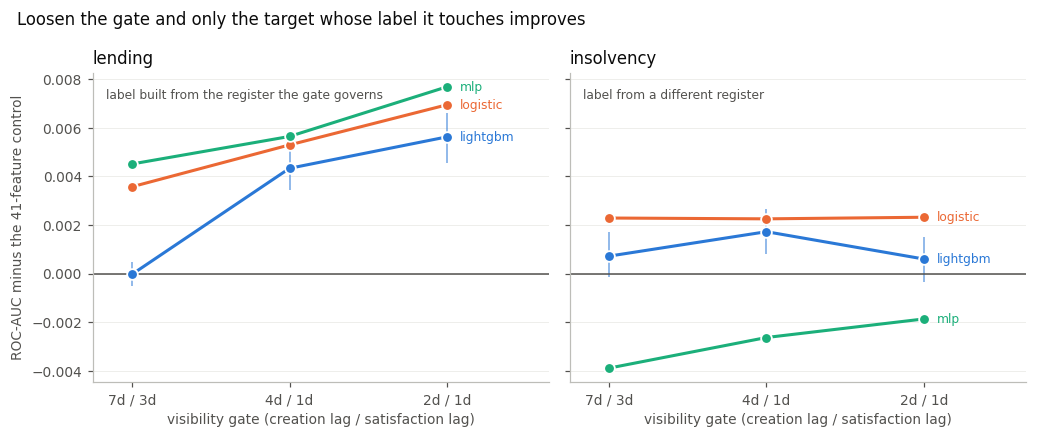

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), sharey=True)
gates = ["7d / 3d", "4d / 1d", "2d / 1d"]
x = np.arange(len(gates))

for ax, t in zip(axes, ("lending", "insolvency")):
    for fam in ("lightgbm", "logistic", "mlp"):
        v = [ladder[(ladder["target"] == t) & (ladder["model"] == fam)
                    & (ladder["gate"] == g)]["d_roc_auc"].iloc[0] for g in gates]
        ax.plot(x, v, "-o", lw=2, ms=7, color=FAMILY[fam], markeredgecolor="white",
                markeredgewidth=1.2, label=fam, zorder=3)
        ax.text(x[-1] + 0.08, v[-1], fam, color=FAMILY[fam], fontsize=8, va="center")
    pl = paired_ladder[paired_ladder["target"] == t].set_index("gate").loc[gates]
    ax.vlines(x, pl["lo"], pl["hi"], color=BLUE, lw=1.2, alpha=0.55, zorder=2)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_xticks(x); ax.set_xticklabels(gates)
    ax.set_xlim(-0.25, len(gates) - 0.35)
    ax.grid(True, axis="y", alpha=0.7); ax.set_axisbelow(True)
    ax.set_xlabel("visibility gate (creation lag / satisfaction lag)")
    ax.set_title(t, loc="left", color=INK)

axes[0].set_ylabel("ROC-AUC minus the 41-feature control")
axes[0].text(0.03, 0.95, "label built from the register the gate governs", transform=axes[0].transAxes,
             fontsize=8, color=MUTED, va="top")
axes[1].text(0.03, 0.95, "label from a different register", transform=axes[1].transAxes,
             fontsize=8, color=MUTED, va="top")
fig.suptitle("Loosen the gate and only the target whose label it touches improves",
             x=0.02, ha="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "17_gate_ladder_contrast"))
plt.show()

In [22]:
p500 = (ladder[ladder["target"] == "lending"]
        .pivot_table(index="model", columns="gate", values="precision_at_500")
        [["7d / 3d", "4d / 1d", "2d / 1d"]])
p500.insert(0, "control", [control.loc[("lending", m), "precision_at_500"] for m in p500.index])
print("lending precision@500 across the ladder")
print(p500.to_string(float_format=lambda v: f"{v:.3f}"))

lending precision@500 across the ladder
gate      control  7d / 3d  4d / 1d  2d / 1d
model                                       
lightgbm    0.282    0.294    0.332    0.406
logistic    0.150    0.188    0.180    0.180
mlp         0.266    0.196    0.238    0.326


The `lending` panel is monotone in **every** model family: the looser the gate, the better the score,
with no exception in nine cells. `precision@500` on LightGBM tells the same story in units a
relationship manager understands, running 0.294, 0.332, 0.406 against a control of 0.282. The paired
intervals on the LightGBM rows put the two looser gates clear of zero.

The `insolvency` panel has no gradient at all. The logistic sits at about +0.0023 at **all three**
gates, which is what a genuine and small feature improvement looks like: present, and indifferent to
the gate. LightGBM is positive but unordered (+0.0007, +0.0017, +0.0006 as the gate loosens); note
that its middle value is individually clear of zero on the paired interval, so this is not "no
effect", it is "an effect that does not care where the gate is".

Being fair to the counter-reading: the `insolvency` MLP row does rise across the ladder
(-0.0039, -0.0026, -0.0019). Two things about it. It is negative throughout, so it is a story about
how much the MLP *loses*, not gains. And it moves over a range of 0.002 in the one family whose seed
noise is 0.017, so it carries no information in either direction and I would not read it. The two
families that can support a reading are flat and unordered.

**That contrast is the finding.** A feature set that is genuinely informative does not care where the
visibility gate is set to within a few days. A feature set that is reading the label early cares a
great deal, and cares in proportion. `lending` cares; `insolvency`, whose label the gate cannot
reach, does not.

The honest reading of the ladder is therefore that some of what `lender_calib` gains on `lending` is
still lookahead rather than signal, and that the leak-averse `lender_calib_hi` (which lands within
0.00003 of the control on LightGBM) is the conservative choice for anything quoted as a lending
result. It also means the calibrated gate should not be treated as obviously safe just because it was
calibrated: the ladder says the lending number is still moving at 4 days.

---

# 9. Pooled precision@N overstates what a relationship manager sees

One more thing the metrics were getting wrong, and it is the one with the most direct effect on how
section 11.5 should be written.

`precision@500` has been computed on both test origins pooled together. A relationship manager does
not work a pooled list. They work **this month's** list. A pooled top-500 can be dominated by one of
the two months, and it can hold the same company twice, once at each origin, which is not a call list
at all.

`evaluate_by_origin` computes the metric per origin, and it is now recorded in `metrics.json` for
every run.

In [23]:
rows = []
for tag in ("refactor_det", "lender_calib"):
    met = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]
    for t, r in met.items():
        for fam, by_origin in r["metrics_by_origin"].items():
            pooled = r["metrics"][fam]
            per = {o: m["precision_at_500"] for o, m in by_origin.items()}
            rows.append({"tag": tag, "target": t, "model": fam,
                         "pooled_p500": pooled["precision_at_500"],
                         **{f"p500_{o[:7]}": v for o, v in per.items()},
                         "spread": max(per.values()) - min(per.values()),
                         "mean_of_origins": float(np.mean(list(per.values())))})
origins_tbl = pd.DataFrame(rows)

# Does the pooled figure even lie between the two months it pools? Counted rather than
# eyeballed off the figure, which is how I got this wrong the first time.
pcols = [c for c in origins_tbl.columns if c.startswith("p500_")]
outside = []
for _, r in origins_tbl.iterrows():
    per = [r[c] for c in pcols if pd.notna(r[c])]
    gap = max(min(r["pooled_p500"] - min(per), 0) or 0,
              max(r["pooled_p500"] - max(per), 0))
    outside.append({"tag": r["tag"], "target": r["target"], "model": r["model"],
                    "outside_month_range": bool(r["pooled_p500"] < min(per)
                                                or r["pooled_p500"] > max(per)),
                    "distance_outside": float(min(abs(r["pooled_p500"] - min(per)),
                                                  abs(r["pooled_p500"] - max(per))))
                    if (r["pooled_p500"] < min(per) or r["pooled_p500"] > max(per)) else 0.0})
outside = pd.DataFrame(outside)
origins_tbl = origins_tbl.merge(outside, on=["tag", "target", "model"])
for tag, g in outside.groupby("tag"):
    big = g[g["outside_month_range"] & (g["distance_outside"] > 0.02)]
    print(f"{tag}: pooled P@500 lies outside the range of its own months in "
          f"{int(g['outside_month_range'].sum())} of {len(g)} rows, "
          f"{len(big)} of them by more than 0.02")
print()

show = origins_tbl[origins_tbl["tag"] == "refactor_det"].drop(columns="tag")
print(show.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(report.save_table(origins_tbl, "17_per_origin_spread",
                        "precision@500 pooled across test origins against the same metric "
                        "computed per origin."))

lender_calib: pooled P@500 lies outside the range of its own months in 9 of 12 rows, 4 of them by more than 0.02
refactor_det: pooled P@500 lies outside the range of its own months in 9 of 12 rows, 6 of them by more than 0.02

        target    model  pooled_p500  p500_2026-01  p500_2026-04  spread  mean_of_origins  p500_2025-10  p500_2025-04  p500_2025-07  outside_month_range  distance_outside
       lending lightgbm        0.282         0.218         0.226   0.008            0.222           NaN           NaN           NaN                 True             0.056
       lending logistic        0.150         0.132         0.148   0.016            0.140           NaN           NaN           NaN                 True             0.002
       lending      mlp        0.266         0.198         0.190   0.008            0.194           NaN           NaN           NaN                 True             0.068
    insolvency lightgbm        0.122         0.116           NaN   0.008            0.112

reports/figures/17_per_origin_p500_spread.pdf


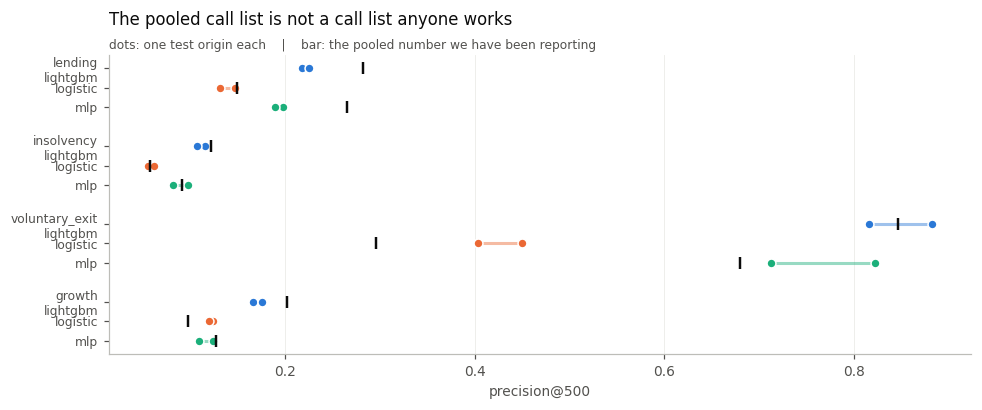

In [24]:
sub = origins_tbl[origins_tbl["tag"] == "refactor_det"]
fig, ax = plt.subplots(figsize=(9, 3.8))
labels, ypos = [], []
i = 0
for t in targets_order:
    for fam in ("lightgbm", "logistic", "mlp"):
        r = sub[(sub["target"] == t) & (sub["model"] == fam)].iloc[0]
        per = [r[c] for c in sub.columns if c.startswith("p500_") and pd.notna(r[c])]
        ax.plot([min(per), max(per)], [i, i], lw=2, color=FAMILY[fam], alpha=0.45,
                solid_capstyle="round")
        ax.scatter(per, [i] * len(per), s=34, color=FAMILY[fam], zorder=3,
                   edgecolor="white", linewidth=1.0)
        ax.scatter([r["pooled_p500"]], [i], s=70, marker="|", color=INK, zorder=4, linewidth=1.6)
        labels.append(fam if fam != "lightgbm" else f"{t}\n{fam}")
        ypos.append(i); i += 1
    i += 1

ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("precision@500")
ax.grid(True, axis="x", alpha=0.7); ax.set_axisbelow(True)
ax.text(0, 1.01, "dots: one test origin each    |    bar: the pooled number we have been reporting",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8, color=MUTED)
ax.set_title("The pooled call list is not a call list anyone works\n", loc="left", color=INK)
fig.tight_layout()
print(report.save_fig(fig, "17_per_origin_p500_spread"))
plt.show()

The spread between the two test origins is routinely larger than the differences we have been
reporting between runs. But the more serious problem is visible in the table above, and I did not
expect it: **in 9 of the 12 rows the pooled number falls outside the range of the two months it
pools**, in both directions. Six of those nine miss by more than 0.02 and three are marginal, at
0.002 to 0.006. It is 9 of 12 on `lender_calib` as well as on `refactor_det`, computed independently:
two runs landing on the same count is what makes this structural rather than a quirk of one fit.

- `lending` LightGBM: pooled 0.282, months 0.218 and 0.226. Pooling **flatters**, because taking the
  best 500 of two months' worth of candidates means going less deep into either list.
- `voluntary_exit` logistic: pooled 0.296, months 0.404 and 0.450. Pooling **penalises**, by 0.11.

The second case can only happen if the scores are not comparable across origins: the pooled top 500
fills up with rows from whichever month the model scores higher in absolute terms, regardless of
which month it ranks better in. A pooled precision@N is therefore not an average of the monthly
figures and cannot be interpreted as one. It is its own quantity, and on `voluntary_exit` it is a
worse quantity than either month.

**What I would change in the report:** quote per-origin `precision@N` with the spread, not the pooled
figure, wherever the number is presented as an operational call list. Keep the pooled figure for
run-to-run comparison, where both runs are pooled the same way and the comparison is still fair. And
stop quoting `precision@N` differences below about 0.01 as findings, since section 4 showed the
bottom 0.002 of that is arithmetic and this section shows the month-to-month variation swamps the
rest.

---

## What to check

Every assertion below is re-derived from disk or from the fits in this notebook, so none of it has to
be taken on trust.

In [25]:
checks = []


def check(name, ok, detail=""):
    checks.append({"check": name, "pass": bool(ok), "detail": detail})


# G2, extended to all three families rather than LightGBM alone.
check("all three model families are bit-identical when fitted twice in one process",
      det["identical"].all(), f"rows differing: {det['rows_differing'].tolist()}")

# G2b, on the recorded runs rather than on synthetic data.
g2b = []
for tag in ("refactor_det", "lender_calib", "lender_calib_hi", "lender_calib_lo",
            "lender_asof21_det", "refactor_growthfix"):
    met = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]
    for t, r in met.items():
        for fam, c in r["metrics_ci"].items():
            for k, b in c.items():
                if isinstance(b, dict):
                    g2b.append(b["lo"] <= r["metrics"][fam][k] <= b["hi"])
check("G2b: every bootstrap interval contains its own point estimate", all(g2b),
      f"{sum(g2b)} of {len(g2b)} interval/point pairs across six runs")

# The dense residual is numerical, not a refit.
check("cross-process differences on the untouched dense paths are below 1e-8",
      moved[moved["model"].isin(["logistic", "mlp"])
            & moved["metric"].isin(["roc_auc", "pr_auc"])]["abs_delta"].max() < 1e-8,
      f"max {moved[moved['model'].isin(['logistic','mlp']) & moved['metric'].isin(['roc_auc','pr_auc'])]['abs_delta'].max():.2e}")

check("row order does not change any metric",
      all(abs(shuf_e[k] - base_e[k]) == 0 for k in ("roc_auc", "pr_auc", "precision_at_500")))

check("BLAS thread count does change the dense predictions",
      not threads["identical_across_thread_counts"].any(),
      f"max abs diff {threads['max_abs_diff'].max():.2e}")

# The MLP seed result Stream C needs.
check("the growth MLP 27-vs-41 difference does not hold its sign across seeds",
      abs(np.sign(paired_seed["delta"]).sum()) != len(SEEDS),
      f"per-seed deltas {np.round(paired_seed['delta'].to_numpy(), 5).tolist()}")

check("the MLP seed range exceeds its row-bootstrap interval width",
      (spread[spread["model"] == "mlp"]["seed_range_over_bootstrap_width"] > 1).all(),
      f"ratios {spread[spread['model']=='mlp']['seed_range_over_bootstrap_width'].round(2).tolist()}")

check("the deterministic families' seed range stays inside their bootstrap width",
      (spread[spread["model"].isin(["lightgbm", "logistic"])]["seed_range_over_bootstrap_width"] < 1).all(),
      f"ratios {spread[spread['model'].isin(['lightgbm','logistic'])]['seed_range_over_bootstrap_width'].round(2).tolist()}")

# The ladder, which is the headline.
lend = ladder[ladder["target"] == "lending"].pivot_table(index="model", columns="gate", values="d_roc_auc")
check("lending improves monotonically as the gate loosens, in all three families",
      bool(((lend["7d / 3d"] < lend["4d / 1d"]) & (lend["4d / 1d"] < lend["2d / 1d"])).all()),
      lend.round(4).to_dict())
ins = ladder[ladder["target"] == "insolvency"].pivot_table(index="model", columns="gate", values="d_roc_auc")
check("insolvency shows no such ordering",
      not bool(((ins["7d / 3d"] < ins["4d / 1d"]) & (ins["4d / 1d"] < ins["2d / 1d"])).all()),
      ins.round(4).to_dict())

check("the paired interval on lending is narrower than the unpaired one and excludes zero",
      (d_lending["roc_auc"]["hi"] - d_lending["roc_auc"]["lo"])
      < (ctrl["roc_auc_hi"] - ctrl["roc_auc_lo"]) and d_lending["roc_auc"]["lo"] > 0,
      f"paired width {d_lending['roc_auc']['hi'] - d_lending['roc_auc']['lo']:.5f} vs "
      f"unpaired {ctrl['roc_auc_hi'] - ctrl['roc_auc_lo']:.5f}")

checks_df = pd.DataFrame(checks)
print(checks_df.to_string(index=False))
print()
print(f"{checks_df['pass'].sum()} of {len(checks_df)} checks pass")
print(report.save_table(checks_df, "17_checks", "Machine-checked assertions for notebook 17."))
assert checks_df["pass"].all(), checks_df[~checks_df["pass"]]

                                                                             check  pass                                                                                                                                                                                                          detail
       all three model families are bit-identical when fitted twice in one process  True                                                                                                                                                                                       rows differing: [0, 0, 0]
                     G2b: every bootstrap interval contains its own point estimate  True                                                                                                                                                                 360 of 360 interval/point pairs across six runs
             cross-process differences on the untouched dense paths are below 1e-8  True                     

---

## For the report

**Drafted paragraphs.** These are written to be pasted into the methods and results chapters.

> **Determinism.** Boosted-tree training was found to be non-reproducible between runs: the same
> model fitted twice on identical inputs returned precision@100 of 0.830 and 0.820. The cause was
> multi-threaded histogram construction, which sums floating-point gradients in thread-completion
> order and thereby reorders ties in the split search. Setting `deterministic=True` and
> `force_col_wise=True` fixes it, at a cost in fitting speed, and all reported runs were re-recorded
> under the corrected settings. Verification consisted of fitting each model family twice within a
> single process and comparing predictions element-wise; all three families returned bit-identical
> vectors. Across processes the dense models (logistic regression and the multi-layer perceptron)
> agree only to approximately nine decimal places, because their BLAS backend varies its reduction
> order with the thread pool it is allocated; this was confirmed directly by refitting under a
> single-threaded pool and observing prediction differences of order 1e-15. The residual is immaterial
> for ROC-AUC but not for precision@N, which is a discontinuous functional of the scores: where the
> ranked scores at the cut are separated by less than the numerical residual, the metric quantises by
> one company. Reported precision@N therefore carries an irreducible +/-1 company of uncertainty
> before any sampling error is counted.

> **Uncertainty quantification.** All reported metrics carry 95% confidence intervals obtained by
> resampling the evaluation rows with replacement (1000 resamples, percentile method). For
> comparisons between runs, which are evaluated on identical companies at identical origins, a paired
> bootstrap is used: rows are resampled once and both models are scored on the same resample, so that
> population variation common to both cancels. The paired interval is roughly an order of magnitude
> narrower than the comparison of two independent intervals and is the appropriate test; on the
> `lending` target the unpaired reading is inconclusive where the paired reading is not. Both
> intervals quantify evaluation-sample noise only and are lower bounds on total uncertainty: they
> exclude the choice of training origins and the refitting of the model. For the multi-layer
> perceptron, whose fit depends on a random initialisation, the refit term dominates: across four
> seeds the growth ROC-AUC ranges over 0.018, several times the width of the row-resampled interval.
> Differences smaller than that are accordingly not interpreted for that model family.

> **Evidence of residual lookahead in the lending target.** The visibility gate was evaluated at three
> settings spanning the calibrated estimate. On the `lending` target, whose label is derived from the
> same charge register the gate governs, the advantage over the control rises monotonically as the
> gate is loosened, in all three model families without exception, and precision@500 rises from 0.294
> to 0.406. On the `insolvency` target, whose label derives from an unrelated register, no such
> ordering exists and the linear model's advantage is constant at +0.0023 across all three settings.
> A feature set that carries genuine information is insensitive to a few days of visibility margin; a
> feature set that partially anticipates its own label is not. The contrast localises the remaining
> lending advantage as at least partly anticipatory, and the leak-averse gate setting is therefore
> preferred for any quoted lending result.

**Figures**

| path | use |
|---|---|
| `reports/figures/17_rank_gap_vs_numerical_wobble.pdf` | methods: why precision@N quantises |
| `reports/figures/17_growth_seed_spread_vs_bootstrap.pdf` | methods: the MLP error bar; also cite in the growth section |
| `reports/figures/17_bootstrap_forest_refactor_det.pdf` | results: the headline table with intervals |
| `reports/figures/17_paired_vs_unpaired.pdf` | methods: why comparisons are paired |
| `reports/figures/17_gate_ladder_contrast.pdf` | **results: the lookahead evidence, the strongest figure we have** |
| `reports/figures/17_per_origin_p500_spread.pdf` | results: why the operational number is per origin |

**Tables**

| path | use |
|---|---|
| `reports/tables/17_run_intervals.csv` / `.tex` | every headline number with its interval |
| `reports/tables/17_gate_ladder_paired_delta.csv` / `.tex` | the ladder with paired intervals |
| `reports/tables/17_gate_ladder_all_families.csv` / `.tex` | the ladder across all three families |
| `reports/tables/17_growth_seed_spread.csv` / `.tex` | the MLP seed evidence |
| `reports/tables/17_rank_gap_fragility.csv` / `.tex` | the precision@N quantisation argument |
| `reports/tables/17_per_origin_spread.csv` / `.tex` | pooled against per-origin |
| `reports/tables/17_checks.csv` / `.tex` | the verification list |

**Three things I did not do, and would want to.**

1. **`threadpool_limits(1)` is not in `train.py`.** It would make the dense fits reproducible across
   processes and, on the evidence above, it would also make them faster on this machine. It changes
   every recorded dense number, so it belongs to a re-run rather than to this notebook.
2. **MLP numbers are single-seed.** Averaging over several seeds inside `run_target` would make
   them quotable. Until that happens the seed term in section 5 is the error bar.
3. **Only LightGBM models were persisted by the staged runner**, so the paired bootstrap could only be
   applied to LightGBM comparisons. Persisting the held-out prediction vectors (a few megabytes per
   run) would let every family be compared properly, and would remove the need to re-score anything.

**One correction to the manifests.** `registration_lag_days` in `manifest.json` records the module
default rather than the gate the lender panel was actually built under, so all four lender runs show
4 regardless of their real setting. The true gates are in `scripts/run_config_staged.py` and
`src/features/charges.py`, and are stated in section 8 above. I have set the explicit value on the
reference configs in `train.py` so future records are right; the four already recorded are wrong in
that one field and correct everywhere else.